# Ferramentas

In [2]:
import pandas as pd
import numpy as np
from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns
import io

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Carregar Arquivo

In [3]:
caminho_do_arquivo = "/content/drive/MyDrive/Arquivos/Dados_Anatel/ibc_brasil_consolidado_corrigido.csv"

try:
    print(f"Carregando o arquivo de: {caminho_do_arquivo}")
    df = pd.read_csv(caminho_do_arquivo, delimiter=';')

    print("\nArquivo carregado com sucesso! Visualização das 5 primeiras linhas:")
    print(df.head())

    print("\nInformações gerais sobre o DataFrame:")
    df.info()
except FileNotFoundError:
    print("\nERRO: Arquivo não encontrado!")
    print("Verifique se o caminho que você colou está correto e se o arquivo existe nesse local no seu Google Drive.")
except Exception as e:
    print(f"Ocorreu um erro: {e}")

Carregando o arquivo de: /content/drive/MyDrive/Arquivos/Dados_Anatel/ibc_brasil_consolidado_corrigido.csv

Arquivo carregado com sucesso! Visualização das 5 primeiras linhas:
    ano sigla_uf  id_municipio    ibc  cobertura_pop_4g5g  fibra  \
0  2021       AC       1200013  51.03             53.3781    100   
1  2021       AC       1200054  48.64             62.9389    100   
2  2021       AC       1200104  51.68             69.2186    100   
3  2021       AC       1200138  49.66             47.5128    100   
4  2021       AC       1200179  42.78             48.9206    100   

   densidade_smp  hhi_smp  densidade_scm  hhi_scm  adensamento_estacoes  
0          59.40       88           0.98       72                  6.54  
1          62.12       60           2.00       21                  6.72  
2          64.52       51           2.03       58                  5.69  
3          62.99       66           1.68       68                  9.72  
4          35.78       86           1.27     

# Preparar Dados e Treinar o Modelo

In [4]:
# Preparar dados e treinar o modelo
print("Iniciando a preparação dos dados...")

# A variável alvo (o que queremos prever)
y = df['ibc']
# As variáveis preditoras (features)
X = df.drop(columns=['ibc', 'sigla_uf', 'id_municipio'])

# Dividir dados em treino e teste (80% para treino, 20% para teste)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Dados preparados.")

print("\nIniciando o treinamento do modelo RandomForestRegressor...")
model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

print("Modelo treinado com sucesso!")

Iniciando a preparação dos dados...
Dados preparados.

Iniciando o treinamento do modelo RandomForestRegressor...
Modelo treinado com sucesso!


# Avaliar a Performance do Modelo

In [5]:
# Avaliar o modelo
print("--- Resultados da Avaliação do Modelo ---")

y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"R-quadrado (R²): {r2:.4f}")
print(f"Erro Médio Absoluto (MAE): {mae:.4f}")

--- Resultados da Avaliação do Modelo ---
R-quadrado (R²): 0.9815
Erro Médio Absoluto (MAE): 1.1710


# Analisar e Visualizar os Fatores Mais Importantes

Gerando o gráfico de importância dos fatores...


/tmp/ipython-input-6-1697358167.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


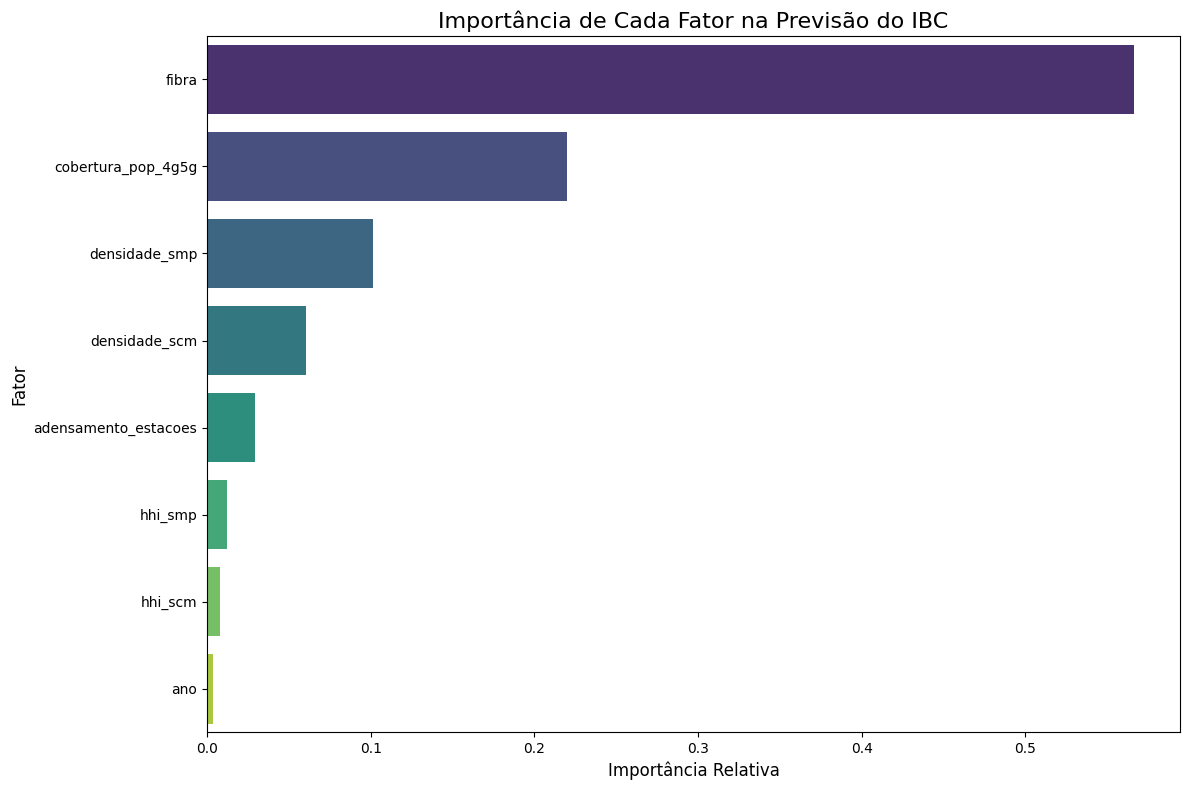


Análise completa!


In [6]:
# Calcular e visualizar a importância dos fatores
print("Gerando o gráfico de importância dos fatores...")

importances = model.feature_importances_
feature_names = X.columns

feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Importância de Cada Fator na Previsão do IBC', fontsize=16)
plt.xlabel('Importância Relativa', fontsize=12)
plt.ylabel('Fator', fontsize=12)
plt.tight_layout()
plt.show()

print("\nAnálise completa!")

# Definição da Função de Previsão

In [8]:
# Verificamos se o modelo treinado existe na memória para evitar erros.
try:
    model
except NameError:
    print("ERRO: O modelo ainda não foi treinado nesta sessão.")
    print("Por favor, execute as células anteriores (Parte 4) para treinar o modelo antes de usar esta função.")


def prever_ibc(ano, fibra, cobertura_pop_4g5g, densidade_smp, densidade_scm,
               adensamento_estacoes=16.0, hhi_smp=47, hhi_scm=56):
    """
    Função para prever o IBC de um município com base nas suas características.
    """
    if 'model' not in globals():
        print("Modelo não está treinado. Não é possível fazer a previsão.")
        return

    # Criar o DataFrame com os dados para a previsão na ordem correta
    dados_previsao = pd.DataFrame({
        'ano': [ano],
        'cobertura_pop_4g5g': [cobertura_pop_4g5g],
        'fibra': [fibra],
        'densidade_smp': [densidade_smp],
        'hhi_smp': [hhi_smp],
        'densidade_scm': [densidade_scm],
        'hhi_scm': [hhi_scm],
        'adensamento_estacoes': [adensamento_estacoes]
    })

    # Fazer a previsão
    previsao = model.predict(dados_previsao)

    # Imprimir o resultado de forma clara
    print(f"--> Para um município com os dados informados, o IBC previsto é: {previsao[0]:.2f}")

print("Função 'prever_ibc' criada com sucesso. Você já pode usá-la nas próximas células.")

Função 'prever_ibc' criada com sucesso. Você já pode usá-la nas próximas células.


# Usando a Função para Simular Cenários

In [10]:
# Testando Cenários
# Você pode alterar os valores abaixo e executar esta célula quantas vezes quiser.

# Cenário 1: O nosso primeiro município hipotético
print("Cenário 1: Nosso primeiro município hipotético.")
prever_ibc(
    ano=2025,
    fibra=100,
    cobertura_pop_4g5g=85.0,
    densidade_smp=70.0,
    densidade_scm=25.0
)

# Cenário 2: O que acontece se a internet fixa (densidade_scm) dobrar?
print("\nCenário 2: Mesmo município, mas com o DOBRO de densidade de internet fixa.")
prever_ibc(
    ano=2025,
    fibra=100,
    cobertura_pop_4g5g=85.0,
    densidade_smp=70.0,
    densidade_scm=50.0  # O valor foi alterado de 25 para 50
)

# Cenário 3: Um município com dados piores
print("\nCenário 3: Um município com infraestrutura mais fraca.")
prever_ibc(
    ano=2025,
    fibra=0,  # Não tem a espinha dorsal de fibra
    cobertura_pop_4g5g=60.0,
    densidade_smp=50.0,
    densidade_scm=10.0
)

Cenário 1: Nosso primeiro município hipotético.
--> Para um município com os dados informados, o IBC previsto é: 59.08

Cenário 2: Mesmo município, mas com o DOBRO de densidade de internet fixa.
--> Para um município com os dados informados, o IBC previsto é: 59.56

Cenário 3: Um município com infraestrutura mais fraca.
--> Para um município com os dados informados, o IBC previsto é: 29.40


# **Projeto de Machine Learning: Análise Preditiva do Índice de Conectividade Brasileiro**

---

## 1. Objetivo do Projeto

O objetivo principal deste projeto é desenvolver e treinar um modelo de **Machine Learning** supervisionado, utilizando o algoritmo *Random Forest*, capaz de **prever com alta acurácia o Índice Brasileiro de Conectividade (ibc)** para qualquer município do país.

Os objetivos secundários são:
* Identificar e quantificar os fatores de infraestrutura e mercado que mais impactam a conectividade.
* Desenvolver uma ferramenta interativa para a **simulação de cenários**, permitindo a análise do impacto de potenciais investimentos e políticas públicas.

---

## 2. Dataset Utilizado

Utilizamos o dataset público do **"Índice Brasileiro de Conectividade"**, com dados originais da Anatel e disponibilizado pela [Base dos Dados](https://basedosdados.org/dataset/ad45c5dc-ecc6-43db-ae2c-45d71939e7c5?tab=userGuide).

* **Conteúdo:** Tabela consolidada contendo 11 variáveis-chave para todos os municípios brasileiros.
* **Divisão:** O conjunto de 22.280 registros foi dividido programaticamente em 80% para **treinamento** e 20% para **teste**.
* **Cobertura Temporal:** Os dados abrangem o período de 2021 a 2024.

---

## 3. Tecnologias e Ferramentas

* **Linguagem:** Python 3
* **Plataforma:** Google Colaboratory (Colab)
* **Bibliotecas Principais:**
    * **Pandas:** Para a importação, manipulação e estruturação dos dados.
    * **Scikit-learn:** Para a implementação do modelo `RandomForestRegressor`, divisão dos dados e cálculo das métricas de performance.
    * **Matplotlib & Seaborn:** Para a visualização de dados e do gráfico de importância dos fatores.

---

## 4. Metodologia e Passos

O projeto foi estruturado seguindo os seguintes passos metodológicos:

1.  **Importação das Bibliotecas e Carregamento dos Dados.**
2.  **Pré-processamento e Divisão:** Definição da variável-alvo (`y`) e das variáveis preditoras (`X`), seguida da divisão em conjuntos de treino e teste.
3.  **Construção e Treinamento do Modelo:** Instanciação do `RandomForestRegressor` e execução do treinamento com o método `.fit()`.
4.  **Avaliação de Performance:** Cálculo do **R-quadrado (R²)** e do **Erro Médio Absoluto (MAE)**.
5.  **Análise de Importância dos Fatores:** Extração do atributo `feature_importances_` para identificar os fatores mais decisivos.
6.  **Desenvolvimento de Ferramenta de Simulação:** Implementação da função `prever_ibc` para permitir testes de cenários "what-if".

---

## 5. Aplicação Prática e Tomada de Decisão Estratégica

A principal vantagem deste modelo é sua capacidade de transformar dados em uma ferramenta de decisão, reduzindo riscos e otimizando o uso de recursos.

#### **Exemplo de Caso de Uso: Alocação de Orçamento**

Imagine um gestor com **R$ 10 milhões** para investir na melhoria da conectividade de um município, com duas propostas concorrentes:

* **Proposta A:** Investir para expandir a **cobertura de sinal 4G/5G** em 15%.
* **Proposta B:** Criar um programa de subsídios para aumentar a **densidade de internet fixa (`densidade_scm`)** em 10%.

**Com o modelo**, podemos realizar uma **Análise de Cenários** quantitativa:

1.  Inserimos os dados atuais do município na função `prever_ibc` para obter o `ibc` de base.
2.  Simulamos a **Proposta A**, aumentando o valor da `cobertura_pop_4g5g`, e obtemos o `ibc` previsto.
3.  Simulamos a **Proposta B**, aumentando o valor da `densidade_scm`, e obtemos o `ibc` previsto.

Ao comparar o `ibc` resultante de cada simulação, o gestor pode identificar qual proposta oferece o maior **Retorno Sobre o Investimento (ROI)**. A decisão deixa de ser uma aposta e passa a ser uma escolha estratégica, fundamentada em uma previsão objetiva, garantindo que os R$ 10 milhões sejam aplicados da forma mais eficaz possível.

In [11]:
# Célula de Código: Demonstração da Ferramenta de Simulação

# Importamos as bibliotecas e definimos a função de previsão.
# NOTA: Este código assume que o DataFrame 'df' e o 'model' treinado
# já existem na sessão do notebook a partir dos passos anteriores.

import pandas as pd

try:
    model
except NameError:
    print("ERRO: O modelo ainda não foi treinado. Por favor, execute as células de treinamento primeiro.")

def prever_ibc(ano, fibra, cobertura_pop_4g5g, densidade_smp, densidade_scm,
               adensamento_estacoes=16.0, hhi_smp=47, hhi_scm=56):
    """
    Função para prever o IBC de um município com base nas suas características.
    """
    if 'model' not in globals():
        print("Modelo não está treinado. Não é possível fazer a previsão.")
        return

    dados_previsao = pd.DataFrame({
        'ano': [ano], 'cobertura_pop_4g5g': [cobertura_pop_4g5g],
        'fibra': [fibra], 'densidade_smp': [densidade_smp],
        'hhi_smp': [hhi_smp], 'densidade_scm': [densidade_scm],
        'hhi_scm': [hhi_scm], 'adensamento_estacoes': [adensamento_estacoes]
    })
    previsao = model.predict(dados_previsao)
    print(f"--> IBC Previsto: {previsao[0]:.2f}")
    return previsao[0]

# --- SIMULAÇÃO DO CASO DE USO ---

print("="*50)
print("Análise de Cenário: Otimização de Investimento de R$ 10 Milhões")
print("="*50)

# 1. Definimos o estado ATUAL do município
print("\nCenário Base (Estado Atual do Município):")
ibc_base = prever_ibc(
    ano=2025, fibra=100, cobertura_pop_4g5g=75.0,
    densidade_smp=65.0, densidade_scm=20.0
)

# 2. Simulamos a Proposta A
print("\nProposta A: Aumentar a cobertura de sinal em 15% (de 75 para 90)")
ibc_proposta_a = prever_ibc(
    ano=2025, fibra=100, cobertura_pop_4g5g=90.0, # <-- Valor alterado
    densidade_smp=65.0, densidade_scm=20.0
)

# 3. Simulamos a Proposta B
print("\nProposta B: Aumentar a densidade de internet fixa em 10% (de 20 para 30)")
ibc_proposta_b = prever_ibc(
    ano=2025, fibra=100, cobertura_pop_4g5g=75.0,
    densidade_smp=65.0, densidade_scm=30.0 # <-- Valor alterado
)

print("\n--- RESULTADO DA ANÁLISE ---")
aumento_a = ibc_proposta_a - ibc_base
aumento_b = ibc_proposta_b - ibc_base

print(f"Impacto da Proposta A: Aumento de {aumento_a:.2f} pontos no IBC.")
print(f"Impacto da Proposta B: Aumento de {aumento_b:.2f} pontos no IBC.")

if aumento_b > aumento_a:
    print("\nConclusão: A Proposta B (aumentar a densidade) oferece o maior Retorno Sobre o Investimento.")
else:
    print("\nConclusão: A Proposta A (aumentar a cobertura) oferece o maior Retorno Sobre o Investimento.")

Análise de Cenário: Otimização de Investimento de R$ 10 Milhões

Cenário Base (Estado Atual do Município):
--> IBC Previsto: 53.46

Proposta A: Aumentar a cobertura de sinal em 15% (de 75 para 90)
--> IBC Previsto: 59.10

Proposta B: Aumentar a densidade de internet fixa em 10% (de 20 para 30)
--> IBC Previsto: 54.94

--- RESULTADO DA ANÁLISE ---
Impacto da Proposta A: Aumento de 5.64 pontos no IBC.
Impacto da Proposta B: Aumento de 1.48 pontos no IBC.

Conclusão: A Proposta A (aumentar a cobertura) oferece o maior Retorno Sobre o Investimento.
